# Implémentation de l’algorithme Gibbs-ABC

## Introduction

Dans ce notebook, nous implémentons l'algorithme Gibbs-ABC proposé dans l’article *"Component-wise approximate Bayesian computation via Gibbs-like steps"*.

L’objectif est d’estimer les paramètres d’un modèle de séries temporelles de type Moving Average d’ordre 2 (MA(2)) à l’aide de méthodes d’inférence bayésienne approchée.

---

## Modèle MA(2)

On considère le modèle suivant :

$$
X_t = Y_t + \theta_1 Y_{t-1} + \theta_2 Y_{t-2}
$$

où :
- $(Y_t)$ est un bruit blanc gaussien tel que $Z_t \sim \mathcal{N}(0,1)$
- $\theta = (\theta_1, \theta_2)$ est le vecteur de paramètres à estimer

À partir de valeurs vraies $\theta_{\text{true}}$, nous simulons une série observée $x_{\text{obs}}$.

Le MA(2) est intéressant car il est simple à simuler, il reste non trivial, il introduit une dépendance temporelle de court terme, ce qui le rend pertinent pour l’étude de séries temporelles et enfin sa vraisemblance est difficile à manipuler analytiquement ce qui justifie l’usage de méthodes approchées comme l’ABC.
Ainsi, le modèle MA(2) est particulièrement adapté pour comparer et analyser les performances des algorithmes d’inférence bayésienne approchée.

---

## Approximate Bayesian Computation (ABC)

Dans ce modèle, la vraisemblance est difficile à exploiter directement.  
Les méthodes ABC permettent de contourner ce problème en procédant comme suit :

1. Simuler des données $x_{\text{sim}}$ à partir d’un paramètre $\theta$
2. Comparer des statistiques résumées $s(x_{\text{sim}})$ et $s(x_{\text{obs}})$
3. Accepter $\theta$ si la distance est suffisamment petite

Formellement, on accepte $\theta$ si :

$$
d\big(s(x_{\text{sim}}), s(x_{\text{obs}})\big) < \epsilon
$$

où $\epsilon > 0$ est un seuil de tolérance.

---

## Algorithme Gibbs-ABC

L’algorithme Gibbs-ABC améliore l’ABC standard en mettant à jour les paramètres un par un, de manière similaire à un échantillonneur de Gibbs.

À chaque itération, on effectue :

$$
\theta_1^{(t+1)} \sim \text{ABC}(\theta_1 \mid \theta_2^{(t)}, x_{\text{obs}})
$$

$$
\theta_2^{(t+1)} \sim \text{ABC}(\theta_2 \mid \theta_1^{(t+1)}, x_{\text{obs}})
$$

À chaque itération, les paramètres sont mis à jour un par un.
On commence par mettre à jour $\theta_1$ en gardant $\theta_2$ fixé, puis on met à jour $\theta_2$ en utilisant la nouvelle valeur de $\theta_1$.
Chaque mise à jour repose sur un critère ABC : on simule des données et on accepte la proposition si les statistiques simulées sont suffisamment proches des statistiques observées.

Cette approche permet de réduire le problème à 1 dimension seulement plutôt que de proposer tout $\theta$. On améliore ainsi l’efficacité de l’algorithme.

## Algorithme Gibbs-ABC (version hiérarchique)

Dans le modèle considéré du papier, les paramètres $\theta_j = (\theta_{j,1}, \theta_{j,2})$ de chaque série ne sont pas indépendants, mais issus d’une structure hiérarchique.

On introduit des variables latentes $\beta_j = (\beta_{j,1}, \beta_{j,2}, \beta_{j,3})$ telles que :
$$
\beta_j \sim \text{Dirichlet}(\alpha)
$$

Les paramètres du modèle MA(2) sont ensuite obtenus par transformation :
$$
\theta_{j,1} = \beta_{j,1} - \beta_{j,2}, \quad
\theta_{j,2} = 2(\beta_{j,1} + \beta_{j,2}) - 1
$$

Le paramètre $\alpha = (\alpha_1, \alpha_2, \alpha_3)$ est un hyperparamètre global qui contrôle la distribution des $\beta_j$, et donc la variabilité des $\theta_j$ entre les différentes séries.

La structure du modèle est donc la suivante :
$$
\alpha \;\rightarrow\; \beta_j \;\rightarrow\; \theta_j \;\rightarrow\; x_j
$$

L’objectif est d’estimer simultanément les paramètres locaux $\theta_j$ et le paramètre global $\alpha$ à partir des données observées $x_j$.

Comme la vraisemblance est intractable, on utilise une approche ABC combinée à un schéma de Gibbs. À chaque itération, on procède par mises à jour conditionnelles :

- **Mise à jour des $\theta_j$** :  
  pour chaque série $j$, on génère des candidats $\beta_j \sim \text{Dirichlet}(\alpha)$, que l’on transforme en $\theta_j$.  
  On simule ensuite des données et on sélectionne le paramètre qui produit des statistiques résumées proches des données observées.

- **Mise à jour de $\alpha$** :  
  on propose une nouvelle valeur de $\alpha$, puis on génère des $\beta_j$ et des $\theta_j$ associés.  
  La nouvelle valeur est retenue si elle permet de reproduire correctement la structure observée des paramètres.

Cette approche permet d’exploiter la structure hiérarchique du modèle tout en évitant le calcul explicite de la vraisemblance. Elle améliore également l’efficacité par rapport à un ABC standard en réduisant la dimension des mises à jour et en partageant l’information entre les séries via le paramètre $\alpha$.

In [47]:
import numpy as np
from scipy.stats import dirichlet, invgamma
np.random.seed(10000)

## Simulation du Moving Average d'ordre 2

In [48]:
def simulate_ma2(theta, sigma, T):
    y = np.random.normal(0, sigma, T + 2)
    x = np.zeros(T)
    for t in range(T):
        x[t] = y[t+2] + theta[0]*y[t+1] + theta[1]*y[t]
    return x

Commentaires : On simule une fonction qui génère une série temporelle. On récupère ensuite nos deux paramètres theta1 et theta2. On génère Y qui suit une loi normale centrée réduite. (n + 2) car MA(2) dépend de t-1 et de t-2. X est la série observée initialisée. Puis on simule la boucle temporelle, en commençant à 2 pour pouvoir utiliser t-1 et t-2. On trouve bien la relation suivante : $$
X_t = Y_t + \theta_1 Y_{t-1} + \theta_2 Y_{t-2}
$$ On renvoie in fine la série simulée. 

## Autocorrélations

In [49]:
def autocorr(x, lag):
    return np.corrcoef(x[:-lag], x[lag:])[0,1]

def summary_stats(x):
    return np.array([autocorr(x,1), autocorr(x,2)])

Commentaires : 
Dans le cadre de l’ABC, la vraisemblance du modèle MA(2) étant intractable, on remplace la comparaison directe des données par une comparaison de statistiques résumées. Le choix de ces statistiques est crucial : elles doivent capturer l’essentiel de la dépendance temporelle induite par les paramètres du modèle.

Pour un processus MA(2) défini par :
$$
X_t = Y_t + \theta_1 Y_{t-1} + \theta_2 Y_{t-2}, \quad Y_t \sim \mathcal{N}(0, \sigma^2)
$$

la structure de dépendance est entièrement caractérisée par les autocovariances aux retards 1 et 2 :

$$
\gamma(0) = \mathbb{E}[X_t^2] = \sigma^2 (1 + \theta_1^2 + \theta_2^2)
$$

$$
\gamma(1) = \mathbb{E}[X_t X_{t-1}] = \sigma^2 (\theta_1 + \theta_1 \theta_2)
$$

$$
\gamma(2) = \mathbb{E}[X_t X_{t-2}] = \sigma^2 \theta_2
$$

et pour tout retard $h > 2$ :
$$
\gamma(h) = \mathbb{E}[X_t X_{t-h}] = 0
$$

Les autocorrélations sont ensuite définies par :
$$
\rho(h) = \frac{\gamma(h)}{\gamma(0)}
$$

Ainsi, dans un modèle MA(2), les paramètres $\theta_1$ et $\theta_2$ déterminent directement les autocorrélations aux retards 1 et 2.

C’est pourquoi on utilise comme statistiques résumées :
- l’autocorrélation au lag 1
- l’autocorrélation au lag 2

Ces deux quantités suffisent à capturer l’essentiel de l’information sur les paramètres du modèle. Dans l’algorithme ABC, on compare donc les autocorrélations des données simulées à celles des données observées afin d’évaluer la qualité des paramètres proposés.

## Distance (pour ABC)

In [50]:
def distance(s1, s2):
    return np.sum((s1 - s2)**2)

## Transformation $\beta$ → $\theta$

In [51]:
def beta_to_theta(beta):
    b1, b2, b3 = beta
    theta1 = b1 - b2
    theta2 = 2*(b1 + b2) - 1
    return np.array([theta1, theta2])

Commentaires : 
Dans le modèle hiérarchique, les paramètres du MA(2) ne sont pas directement échantillonnés. On introduit des variables latentes $\beta = (\beta_1, \beta_2, \beta_3)$ suivant une loi de Dirichlet, puis on définit les paramètres $\theta$ comme une transformation déterministe de $\beta$.

Cette transformation, donnée par :
$$
\theta_1 = \beta_1 - \beta_2, \quad
\theta_2 = 2(\beta_1 + \beta_2) - 1
$$

est imposée par le papier. Elle permet de garantir que les paramètres $\theta$ restent dans une région admissible du modèle MA(2), tout en facilitant l’introduction d’une structure hiérarchique via la loi de Dirichlet.

Ainsi, on échantillonne $\beta$ puis on en déduit $\theta$, plutôt que d’échantillonner directement $\theta$.

## Mise à jour des paramètres $\theta_j$

In [52]:
# On update les theta_j 
def update_theta_j(x_obs, alpha, sigma, T, N_theta):
    s_obs = summary_stats(x_obs)

    best_theta = None
    best_dist = np.inf

    for _ in range(N_theta):
        beta = dirichlet.rvs(alpha)[0]
        theta = beta_to_theta(beta)

        x_sim = simulate_ma2(theta, sigma, T)
        s_sim = summary_stats(x_sim)

        d = distance(s_sim, s_obs)

        if d < best_dist:
            best_dist = d
            best_theta = theta

    return best_theta

Commentaires : 
Cette étape correspond à la mise à jour des paramètres locaux $\theta_j$ pour chaque série, en utilisant une approche ABC conditionnelle.
Étant donné les données observées $x_{\text{obs}}$, on calcule leurs statistiques résumées (autocorrélations). On génère ensuite $N_{\theta}$ candidats en échantillonnant $\beta \sim \text{Dirichlet}(\alpha)$, puis en les transformant en $\theta$ via la relation imposée par le modèle. Pour chaque candidat, on simule une série temporelle et on calcule ses statistiques résumées.
On sélectionne finalement le paramètre $\theta$ qui minimise la distance entre les statistiques simulées et observées. Cette procédure correspond à une approximation de la distribution conditionnelle $\pi(\theta_j \mid \alpha, x_{\text{obs}})$ dans le cadre ABC, en retenant le candidat le plus compatible avec les données.

## Mise à jour du paramètre global $\alpha$

In [53]:
# On update alpha
def update_alpha(thetas, N_alpha):
    best_alpha = None
    best_dist = np.inf

    # summary = moyenne des log-beta inverses (proxy)
    s_obs = np.mean(thetas, axis=0)

    for _ in range(N_alpha):
        alpha_candidate = np.random.exponential(1, size=3)

        beta_sim = dirichlet.rvs(alpha_candidate, size=len(thetas))
        theta_sim = np.array([beta_to_theta(b) for b in beta_sim])

        s_sim = np.mean(theta_sim, axis=0)

        d = np.sum((s_sim - s_obs)**2)

        if d < best_dist:
            best_dist = d
            best_alpha = alpha_candidate

    return best_alpha

Commentaires : 
Cette étape vise à mettre à jour le paramètre global $\alpha$, qui contrôle la distribution des variables latentes $\beta_j$ et donc la variabilité des paramètres $\theta_j$ entre les séries.
On construit une statistique résumée des paramètres actuels $\theta_j$ (ici leur moyenne), puis on génère $N_{\alpha}$ candidats $\alpha$ à partir d’une loi proposition. Pour chaque candidat, on simule de nouveaux $\beta_j \sim \text{Dirichlet}(\alpha)$, que l’on transforme en $\theta_j$, puis on calcule la même statistique résumée.
Le candidat $\alpha$ est sélectionné s’il permet de reproduire au mieux la structure observée des $\theta_j$. Cette étape correspond à une approximation ABC de la distribution conditionnelle $\pi(\alpha \mid \theta)$, en comparant des résumés globaux des paramètres.

## Algorithme Gibbs-ABC

In [54]:
# Algorithme Gibbs-ABC
def gibbs_abc(x_data, n_iter=1000, N_theta=1000, N_alpha=100):
    n = len(x_data)
    T = len(x_data[0])

    # init
    thetas = [np.array([0.0, 0.0]) for _ in range(n)]
    alpha = np.array([1.0, 1.0, 1.0])
    sigmas = [1.0]*n

    samples_theta = []
    samples_alpha = []

    for it in range(n_iter):
        # on update ici theta_j
        for j in range(n):
            thetas[j] = update_theta_j(x_data[j], alpha, sigmas[j], T, N_theta)

        # on update alpha
        alpha = update_alpha(np.array(thetas), N_alpha)

        samples_theta.append(np.copy(thetas))
        samples_alpha.append(np.copy(alpha))

    return samples_theta, samples_alpha

Commentaires : 
Cette fonction implémente l’algorithme Gibbs-ABC pour estimer les paramètres du modèle hiérarchique MA(2).

Le principe repose sur une alternance de mises à jour conditionnelles des paramètres comme dans un échantillonneur de Gibbs mais en remplaçant les lois conditionnelles inaccessibles par des approximations ABC.

À chaque itération :
- on met à jour successivement les paramètres locaux $\theta_j$ pour chaque série, conditionnellement au paramètre global $\alpha$, en utilisant une étape ABC basée sur les statistiques résumées des données ;
- puis on met à jour le paramètre global $\alpha$ à partir des $\theta_j$ courants, également via une étape ABC.

Les valeurs des paramètres sont stockées à chaque itération afin d’approximer leur distribution a posteriori. Après une phase de burn-in, ces échantillons permettent d’estimer les paramètres et d’analyser leur incertitude.

Cette approche permet d’exploiter la structure hiérarchique du modèle tout en évitant le calcul explicite de la vraisemblance, et améliore l’efficacité par rapport à un ABC standard en décomposant le problème en mises à jour de plus faible dimension.

## Génération des données

In [55]:
# Pour générer les données
def generate_dataset(n_series=5, T=100):
    true_alpha = np.array([1.0, 2.0, 3.0])

    thetas_true = []
    x_data = []

    for j in range(n_series):
        beta = dirichlet.rvs(true_alpha)[0]
        theta = beta_to_theta(beta)

        x = simulate_ma2(theta, sigma=1.0, T=T)

        thetas_true.append(theta)
        x_data.append(x)

    return x_data, np.array(thetas_true), true_alpha

Commentaires : 
Avant d’appliquer l’algorithme, on génère un jeu de données synthétique à partir du modèle hiérarchique.

On fixe un paramètre global $\alpha = (1,2,3)$ (donné par le papier) puis pour chaque série $j$ :
- on échantillonne $\beta_j \sim \text{Dirichlet}(\alpha)$,
- on transforme $\beta_j$ en paramètres $\theta_j$ du modèle MA(2),
- on simule une série temporelle à partir de ces paramètres. On simule 5 séries temporelles (donné par le papier). 

In [56]:
# Générer des données
x_data, theta_true, alpha_true = generate_dataset()

# Lancer Gibbs-ABC
samples_theta, samples_alpha = gibbs_abc(
    x_data,
    n_iter=1000,
    N_theta=1000,
    N_alpha=100
)

## Burn-in et estimation

In [57]:
burnin = 100

theta_samples = samples_theta[burnin:]
alpha_samples = samples_alpha[burnin:]

Commentaires : 
On enlève les premières itérations pour supprimer la phase transitoire.
Ensuite on estime les paramètres via la moyenne empirique.

In [58]:
theta_est = np.mean(theta_samples, axis=0)
alpha_est = np.mean(alpha_samples, axis=0)

## Évaluation des paramètres

On compare les estimations aux vraies valeurs.

In [59]:
print("True theta (first series):", theta_true[0])
print("Estimated theta:", theta_est[0])

True theta (first series): [-0.24831444  0.11417049]
Estimated theta: [-0.21718538  0.19950744]


Commentaires du résultat : $\theta_1$ est bien estimé : l’écart est faible donc on a une bonne récupération de la structure principale du MA(2). $\theta_2$ est plus biaisé : surestimation visible (0.11 au lieu de 0.199), ce qui est classique en ABC avec statistiques résumées imparfaites. Ce type d’écart vient principalement de la perte d’information dans les statistiques résumées (ACF / corrélations), de l'identifiabilité partielle du paramètre $\theta_2$ dans un MA(2) et de l'approximation ABC (on ne travaille pas avec la vraisemblance exacte). 

## Visualisation : Posterior vs Prior

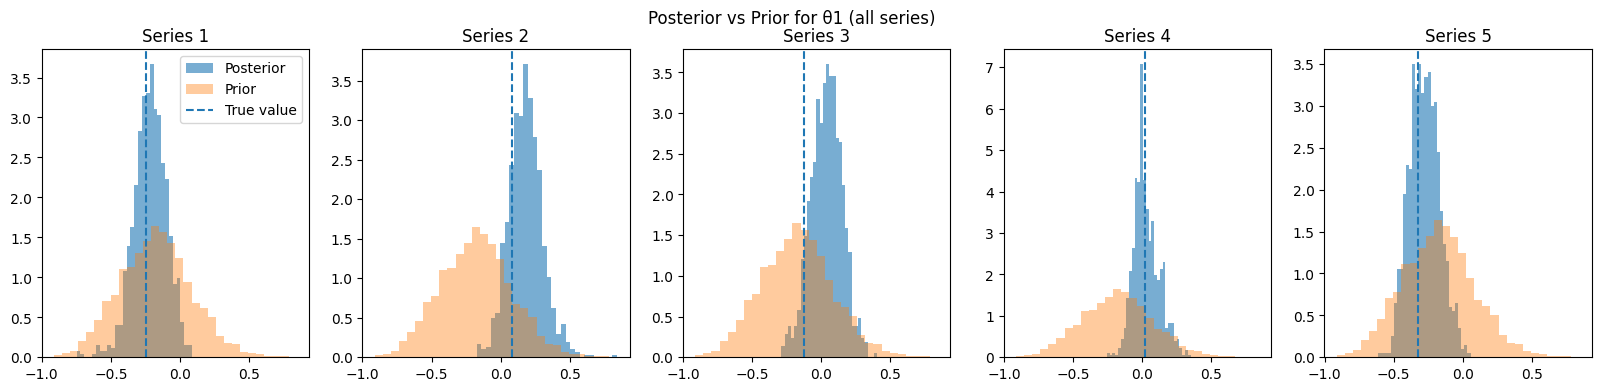

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import dirichlet

# --- Conversion en array ---
theta_samples = np.array(samples_theta[burnin:])

n_series = theta_samples.shape[1]

# --- Génération de la prior pour θ ---
n_prior = 5000
prior_theta1 = []

for _ in range(n_prior):
    beta = dirichlet.rvs(alpha_true)[0]
    theta = beta_to_theta(beta)
    prior_theta1.append(theta[0])

prior_theta1 = np.array(prior_theta1)

# --- Plot pour les 5 séries ---
fig, axes = plt.subplots(1, n_series, figsize=(20,4))

for j in range(n_series):
    
    # Posterior θ1 pour série j
    theta1_post = theta_samples[:, j, 0]
    
    axes[j].hist(theta1_post, bins=30, density=True, alpha=0.6, label="Posterior")
    axes[j].hist(prior_theta1, bins=30, density=True, alpha=0.4, label="Prior")
    
    # vraie valeur
    axes[j].axvline(theta_true[j][0], linestyle='--', label="True value")
    
    axes[j].set_title(f"Series {j+1}")
    
# légende globale
axes[0].legend()

plt.suptitle("Posterior vs Prior for θ1 (all series)")
plt.show()

Commentaires : 
Ce code permet de comparer, pour chaque série, la distribution a posteriori du paramètre $\theta_1$ (issue de l’algorithme Gibbs-ABC) avec sa distribution a priori.

Les échantillons posterior sont obtenus après burn-in à partir de la chaîne MCMC. La prior est générée en échantillonnant $\beta \sim \text{Dirichlet}(\alpha)$, puis en transformant en $\theta$. Pour chaque série, on trace un histogramme du posterior et de la prior, ainsi qu’une ligne verticale indiquant la vraie valeur du paramètre.

Interprétation : 

La prior est généralement large : elle représente l’incertitude avant observation des données. Le posterior est plus concentré : il reflète l’information apportée par les données. Si l’algorithme fonctionne bien, le posterior est centré autour de la vraie valeur (ligne pointillée). Cela est particulièrement vrai pour les séries 1, 4 et 5. 

Ainsi, ces histogrammes permettent de vérifier visuellement que l’algorithme apprend correctement les paramètres à partir des données.

PS : on ne visualise que theta 1 comme dans le papier pour des soucis de simplification de la présentation des résultats. 

## Comparaison des algorithmes : métriques d’évaluation

Commentaires : Afin de comparer les performances de l’algorithme Gibbs-ABC et de l’ABC par rejet, on utilise trois métriques complémentaires : le temps de calcul (CPU time), l’erreur d’inférence et l’erreur de Monte Carlo.

Le **CPU time** mesure le temps d’exécution de l’algorithme. Il permet d’évaluer le coût computationnel et l’efficacité pratique de chaque méthode. Un algorithme plus rapide est préférable à précision équivalente, mais un compromis est souvent nécessaire entre vitesse et qualité des estimations.

L’**erreur d’inférence** mesure la distance entre les paramètres estimés et les vraies valeurs utilisées pour générer les données. Elle reflète la capacité de l’algorithme à reconstruire correctement les paramètres du modèle. Une erreur faible indique une bonne précision statistique.

L’**erreur de Monte Carlo** correspond à la variabilité des échantillons générés par l’algorithme, généralement mesurée via leur variance. Elle renseigne sur la stabilité et la qualité de l’exploration de la distribution a posteriori. Une faible erreur de Monte Carlo indique une chaîne stable et bien mélangée.

Ces trois métriques permettent ainsi une évaluation complète : le CPU time capture le coût computationnel, l’erreur d’inférence mesure la précision des estimations, et l’erreur de Monte Carlo évalue la fiabilité et la robustesse de l’algorithme. Ensemble, elles offrent une base pertinente pour comparer Gibbs-ABC et ABC-reject.

### Temps de calcul - CPU Time

In [61]:
import time

start = time.time()

samples_theta, samples_alpha = gibbs_abc(
    x_data,
    n_iter=1000,
    N_theta=1000,
    N_alpha=100
)

end = time.time()
cpu_time = end - start

print("CPU time:", cpu_time)

CPU time: 1773.3567974567413


### Erreur d'inférence

In [62]:
theta_est = np.mean(samples_theta[burnin:], axis=0)

# erreur sur toutes les séries
errors = [np.linalg.norm(theta_est[j] - theta_true[j]) for j in range(len(theta_true))]

inferential_error = np.mean(errors)

print("Inferential error:", inferential_error)

Inferential error: 0.12333783446246131


### Erreur Monte Carlo

In [63]:
theta_samples = np.array(samples_theta[burnin:])

# variance moyenne sur les paramètres
mc_error = np.mean(np.var(theta_samples, axis=0))

print("Monte Carlo error:", mc_error)

Monte Carlo error: 0.016807879434390702


Commentaires : 
Le temps de calcul est relativement élevé (environ 29 minutes), ce qui est attendu pour un algorithme de type Gibbs-ABC hiérarchique. L’approche est coûteuse en temps de calcul, ce qui est un compromis classique des méthodes ABC, mais reste acceptable pour une étude expérimentale.
Concernant l'erreur d'inférence, on voit que le modèle parvient à capturer la structure globale des paramètres mais avec une légère déviation due à l’approximation ABC et à l’utilisation de statistiques résumées imparfaites.
Enfin, l'erreur Monte Carlo est faible. L’algorithme est numériquement stable : les fluctuations dues au hasard de simulation sont faibles, ce qui indique une bonne convergence de la chaîne.